# Optimisation of a rod shape with RFT

## Imports

In [6]:
import numpy as np
import jax.numpy as jnp
import jax
import plotly.graph_objects as go


In [7]:
np.set_printoptions(linewidth=120, precision=3)

## Parameters

In [8]:
NUM_POINTS = 16
MAX_CURVATURE = 25. / NUM_POINTS

## Parametrisation of tangent vector

In [9]:
def skew_symmetric(v):
    """ Returns the skew-symmetric matrix of a 3D vector. """
    return jnp.array([[0, -v[2], v[1]], 
                      [v[2], 0, -v[0]], 
                      [-v[1], v[0], 0]])

In [10]:
@jax.jit
def compute_tangent_vector(params):
    """
    Computes tangent vectors from the given parameters using spherical coordinates with a cumsum-based 
    evolution, and scaling with MAX_CURVATURE.
    """

    # Scale params for cumsum (this will evolve the angles over the points)
    theta = MAX_CURVATURE * jnp.cumsum(2 * params[:NUM_POINTS] - 1)  # colatitude (spherical coordinate)
    phi   = MAX_CURVATURE * jnp.cumsum(2 * params[NUM_POINTS:] - 1)  # longitude (spherical coordinate)

    # Compute the tangent vector using spherical coordinates
    x = jnp.sin(theta) * jnp.cos(phi)
    y = jnp.sin(theta) * jnp.sin(phi)
    z = jnp.cos(theta)

    # Stack the x, y, z coordinates to form the tangent vectors
    tangent_vectors = jnp.stack([x, y, z], axis=-1)

    return tangent_vectors

## Functions `calculation_angle`

In [11]:
levicivita = np.array(
    [
        [[0.0, 0.0, 0.0], [0.0, 0.0, 1.0], [0.0, -1.0, 0.0]],
        [[0.0, 0.0, -1.0], [0.0, 0.0, 0.0], [1.0, 0.0, 0.0]],
        [[0.0, 1.0, 0.0], [-1.0, 0.0, 0.0], [0.0, 0.0, 0.0]],
    ]
)

In [12]:
@jax.jit
def compute_T(positions_z):
    """Compute the transformation matrix T more efficiently."""
    skew_p = jax.vmap(skew_symmetric)(positions_z)  # (NUM_POINTS, 3, 3)
    I_broadcasted = jnp.tile(jnp.eye(3), (positions_z.shape[0], 1, 1))  # (NUM_POINTS, 3, 3)
    return jnp.concatenate([I_broadcasted, -skew_p], axis=-1)  # (NUM_POINTS, 3, 6)


@jax.jit
def compute_R(tangent_vector):
    """Compute R using vmap and precomputed -2I."""
    outer_tt = jax.vmap(lambda t: jnp.outer(t, t))(tangent_vector)  # (NUM_POINTS, 3, 3)
    return outer_tt - 2 * jnp.eye(3)  # Elementwise subtraction

@jax.jit
def compute_R_(T, R):
    """Compute R_ using a more efficient einsum contraction."""
    return -jnp.einsum("nji,njk,nkl->il", T, R, T, optimize=True)



In [13]:
def calculation_angle(params):   
    tangent_vector = compute_tangent_vector(params)
    
    # Initialize position array and compute cumulative sum
    positions_x = jnp.cumsum(jnp.vstack([jnp.zeros((1, 3)), tangent_vector]), axis=0)  # Add initial zero position and compute cumsum
    
    # Compute positions_z and center_of_mass
    positions_z = (positions_x[1:] + positions_x[:-1]) / 2
    
    # Compute the resistance matrix R_
    T = compute_T(positions_z)  
    R = compute_R(tangent_vector)  
    R_= compute_R_(T, R) 

    # Compute the mobility matrix M_
    M_ = jnp.linalg.inv(R_)
        
    # calculation of submatrices
    mu_tt = M_[:3,:3]
    mu_tr = M_[:3,3:]
    mu_rt = M_[3:,:3]
    mu_rr = M_[3:,3:]
    assert np.allclose(mu_rt, mu_tr.T, atol=1e-5), "Mmean not symmetric"
    
    # Extract submatrices (wrt center of mass)
    center_of_mass = jnp.mean(positions_z, axis=0)
    delta_cross = skew_symmetric(center_of_mass)
    M2 = mu_rt + mu_rr @ delta_cross
    M1 = mu_tt + mu_tr @ delta_cross - delta_cross @ M2
    print("Matrices wrt center of mass")  
    print("Matrix M1\n", M1)
    print("Matrix M2\n", M2)
    assert np.allclose(M1, M1.T, atol=1e-5), "M1 not symmetric"

    # Extract submatrices (wrt hydrodynamic mobility center) (From Kim & Karila 5.3.2)
    trcmcinv = jnp.linalg.inv(np.trace(mu_rr) * np.eye(3) - mu_rr)
    x_cm = 0.5 * jnp.einsum("ij,jkl,kl->i", trcmcinv, levicivita, mu_rt - mu_rt.transpose())    
    delta_cross = skew_symmetric(x_cm)
    M2 = mu_rt + mu_rr @ delta_cross
    M1 = mu_tt + mu_tr @ delta_cross - delta_cross @ M2
    print("\nMatrices wrt hydrodynamic center of motility")  
    print("Matrix M1\n", M1)
    print("Matrix M2\n", M2)
    assert np.allclose(M1, M1.T, atol=1e-5), "M1 not symmetric"
    assert np.allclose(M2, M2.T, atol=1e-5), "M2 not symmetric"

    # Compute complex eigenvalues and eigenvectors of M2
    eigvals1, _ = np.linalg.eigh(M1)  # General eigendecomposition
    eigvals2, eigvecs2 = np.linalg.eig(M2)  # General eigendecomposition
    assert np.all(eigvals1 >= 0), "M1 is not definite positive"

    # Boolean mask: which eigenvalues are real?
    real_mask = np.abs(np.imag(eigvals2)) < 1e-6

    # Replace non-real eigenvectors with zero columns
    real_eigvecs = jnp.real(eigvecs2[:,real_mask])  # Still (3,n), avoids dynamic indexing

    # Compute M1 * eigenvectors
    M1_eigvecs = M1 @ real_eigvecs  # (3,n)
    velocity = M1_eigvecs / jnp.linalg.norm(M1_eigvecs, axis=0, keepdims=True) # (3, n) / (n,) = (3, n)

    # Compute cos(angle) safely
    cos_angles = np.einsum("ij,ij->j", real_eigvecs, M1_eigvecs) / np.linalg.norm(M1_eigvecs, axis=0)

    # Mask out invalid values
    cos_angles = np.real(cos_angles)
    print("\nEigenvalues of M2:", eigvals2)
    print("Eigenvalues of M2 (real only):", eigvals2[real_mask])
    print("Cos angles:", cos_angles)

    print("Angle:",(np.arccos(cos_angles)) * 180 / np.pi, "°")
    
    return cos_angles, real_eigvecs.T, velocity.T, center_of_mass, x_cm

In [14]:
params = jax.random.uniform(jax.random.PRNGKey(0), shape=(2 * NUM_POINTS,), minval=0, maxval=1)
print(params.shape)
calculation_angle(params);

(32,)
Matrices wrt center of mass
Matrix M1
 [[0.037 0.002 0.001]
 [0.002 0.038 0.001]
 [0.001 0.001 0.039]]
Matrix M2
 [[-1.212e-03 -1.168e-04 -3.381e-05]
 [-4.320e-05  6.018e-04  2.336e-03]
 [-7.397e-04  5.907e-04  2.017e-03]]

Matrices wrt hydrodynamic center of motility
Matrix M1
 [[0.037 0.002 0.001]
 [0.002 0.038 0.001]
 [0.001 0.001 0.039]]
Matrix M2
 [[-0.001  0.    -0.001]
 [ 0.     0.001  0.001]
 [-0.001  0.001  0.001]]

Eigenvalues of M2: [-0.001  0.     0.003]
Eigenvalues of M2 (real only): [-0.001  0.     0.003]
Cos angles: [0.998 1.    0.998]
Angle: [4.026 1.214 3.682] °


## Functions `optimize_params`

In [15]:
def optimize_params(
    # init_params,
    num_random_init=100,
    learning_rate=0.03,
    max_iters=1000,
    momentum = 0.9,  # Tune this (0.8 - 0.95 works well)
):
    """Optimizes both delta and radii using gradient descent with constraints.
    
    - Randomly samples `num_random_params` initial parameter sets.
    - Selects the best initial set by optimizing delta.
    - Performs gradient descent on both delta and parameters.
    """
    
    @jax.jit
    def cos_angle(params):
        """Computes cos(angle) for given delta and radii."""
        tangent_vector = compute_tangent_vector(params)
        
        # Initialize position array and compute cumulative sum
        positions_x = jnp.cumsum(jnp.vstack([jnp.zeros((1, 3)), tangent_vector]), axis=0)  # Add initial zero position and compute cumsum
        
        # Compute positions_z and center_of_mass
        positions_z = (positions_x[1:] + positions_x[:-1]) / 2
        
        # Compute the resistance matrix R_
        T = compute_T(positions_z)  
        R = compute_R(tangent_vector)  
        R_= compute_R_(T, R) 

        # Compute the mobility matrix M_
        M_ = jnp.linalg.inv(R_)

        # calculation of submatrices
        mu_tt = M_[:3,:3]
        mu_tr = M_[:3,3:]
        mu_rt = M_[3:,:3]
        mu_rr = M_[3:,3:]

        # Extract submatrices (wrt hydrodynamic mobility center) (From Kim & Karila 5.3.2)
        trcmcinv = jnp.linalg.inv(jnp.trace(mu_rr) * jnp.eye(3) - mu_rr)
        x_cm = 0.5 * jnp.einsum("ij,jkl,kl->i", trcmcinv, levicivita, mu_rt - mu_rt.T)    
        delta_cross = skew_symmetric(x_cm)
        M2 = mu_rt + mu_rr @ delta_cross
        M1 = mu_tt + mu_tr @ delta_cross - delta_cross @ M2

        # Compute eigenvalues and eigenvectors of symmetric M2
        _, eigvecs = jnp.linalg.eigh(M2)  # Differentiable & JIT-friendly

        # Project eigenvectors onto M1
        M1_eigvecs =  M1 @ eigvecs  

        # Compute cosines of angles
        cos_angles = jnp.einsum("ij,ij->j", eigvecs, M1_eigvecs) / (
            jnp.linalg.norm(M1_eigvecs, axis=0) + 1e-16  # Avoid division by zero
        )
        max_cos_angle = jnp.max(cos_angles)

        return max_cos_angle

    def constraints_params(params):
        params = jnp.clip(params, 0, 1)
        return params

    # Generate multiple random initializations
    random_inits = jax.random.uniform(jax.random.PRNGKey(0), shape=(num_random_init, 2*NUM_POINTS), minval=0.4, maxval=0.6)

    # Evaluate the initial cos_angle for each set
    cos_angles = jax.vmap(cos_angle)(random_inits)

    # Select the best starting parameters (smallest cos_angle)
    best_idx = jnp.argmin(cos_angles)
    params = random_inits[best_idx]

    print(f"Selected best initialization with cos_angle={cos_angles[best_idx]:.6f}")

    # Initialize best parameters tracking
    best_parameters = params
    best_cos_angle = cos_angle(params)
    grad_threshold = 1  # Threshold for smoothing

    grad_cos_angle = jax.jit(jax.grad(cos_angle))
    velocity = jnp.zeros_like(params)  # Initialize velocity for momentum
    cos_angle_history = []
    
    for i in range(max_iters):
        grad = grad_cos_angle(params)
        grad_norm = jnp.linalg.norm(grad)

        # Smoothly scale gradient if too large
        scaling_factor = jnp.minimum(1.0, grad_threshold / (grad_norm + 1e-8))  # Smooth rescaling
        grad = grad * scaling_factor  

        # Compute new parameters
        velocity = momentum * velocity - learning_rate * grad
        params = params + velocity  # Update parameters

        # Enforce constraints
        params = constraints_params(params)
        
        # Compute current cos_angle
        current_cos_angle = cos_angle(params)

        # Track the best parameters based on minimum cos_angle
        if current_cos_angle < best_cos_angle:
            best_cos_angle = current_cos_angle
            best_parameters = params


        # Append current iteration data for plotting
        cos_angle_history.append(current_cos_angle)

        # Screen display of iterative process
        if i % 10000 == 0:
            param_str = (
                f"{params[:2]} ... {params[-2:]}" if len(params) > 4 else str(params)
            )
            print(f"Iter: {i:5d} | Best cos_angle: {best_cos_angle:.6f} | "
                f"Current cos_angle: {current_cos_angle:.6f} | "
                f"Params: {param_str} | Grad norm: {grad_norm:.4f}")

    return best_parameters, best_cos_angle

## Optimisation

In [16]:
params, cos_angles = optimize_params(
    learning_rate=0.0001, 
    max_iters=1000000,
    momentum=0.9,
)

Selected best initialization with cos_angle=0.992873
Iter:     0 | Best cos_angle: 0.992839 | Current cos_angle: 0.992839 | Params: [0.488 0.52 ] ... [0.428 0.593] | Grad norm: 0.5821
Iter: 10000 | Best cos_angle: 0.948872 | Current cos_angle: 0.948872 | Params: [0.49  0.514] ... [0.465 0.608] | Grad norm: 36.8202
Iter: 20000 | Best cos_angle: 0.946679 | Current cos_angle: 0.949970 | Params: [0.492 0.51 ] ... [0.461 0.604] | Grad norm: 77.6383
Iter: 30000 | Best cos_angle: 0.946027 | Current cos_angle: 0.962978 | Params: [0.493 0.508] ... [0.456 0.6  ] | Grad norm: 18.6481
Iter: 40000 | Best cos_angle: 0.945963 | Current cos_angle: 0.946933 | Params: [0.494 0.507] ... [0.45  0.596] | Grad norm: 4.7391
Iter: 50000 | Best cos_angle: 0.945576 | Current cos_angle: 0.951465 | Params: [0.495 0.505] ... [0.443 0.591] | Grad norm: 87.3229
Iter: 60000 | Best cos_angle: 0.945417 | Current cos_angle: 0.945820 | Params: [0.497 0.504] ... [0.437 0.587] | Grad norm: 4.7530
Iter: 70000 | Best cos_ang

## Plotting

In [17]:
cos_angles, eigenvecs, velocities, x_g, x_cm = calculation_angle(params)

# Calculate eigenvectors and direction of descent velocity
n_min = np.argmin(cos_angles)
eigenvec = eigenvecs[n_min]
velocity = velocities[n_min]
angle = 180 * jnp.arccos(cos_angles[n_min]) / jnp.pi

Matrices wrt center of mass
Matrix M1
 [[ 3.131e-02 -3.295e-05 -2.119e-05]
 [-3.295e-05  3.127e-02 -1.651e-05]
 [-2.119e-05 -1.651e-05  6.219e-02]]
Matrix M2
 [[ 7.975e-06 -4.867e-06  1.105e-05]
 [ 1.311e-05 -8.055e-06 -6.191e-06]
 [ 4.321e-07 -1.371e-06 -2.633e-07]]

Matrices wrt hydrodynamic center of motility
Matrix M1
 [[ 3.131e-02 -3.285e-05 -2.115e-05]
 [-3.285e-05  3.127e-02 -1.644e-05]
 [-2.115e-05 -1.644e-05  6.219e-02]]
Matrix M2
 [[ 7.851e-06  4.979e-06  1.101e-05]
 [ 3.338e-06 -8.057e-06 -6.289e-06]
 [ 1.097e-05 -6.258e-06 -1.373e-07]]

Eigenvalues of M2: [ 1.553e-05 -1.545e-05 -4.220e-07]
Eigenvalues of M2 (real only): [ 1.553e-05 -1.545e-05 -4.220e-07]
Cos angles: [0.944 0.944 0.944]
Angle: [19.284 19.285 19.269] °


In [18]:
tangent_vector = compute_tangent_vector(params)
positions_x = jnp.cumsum(jnp.vstack([jnp.zeros((1, 3)), tangent_vector]), axis=0)  # Add initial zero position and compute cumsum

In [19]:
# Extract X, Y, Z coordinates
x, y, z = positions_x.T
xc, yc, zc = x_g
xm, ym, zm = x_cm

# Find the min and max values for x, y, and z
min_val = min(np.min(x), np.min(y), np.min(z)) - 5
max_val = max(np.max(x), np.max(y), np.max(z)) + 5

# Plotting
fig = go.Figure()

# Add the rod as a line plot
fig.add_trace(go.Scatter3d(
    x=x, y=y, z=z, 
    mode='lines+markers', 
    line=dict(color='blue', width=4),
    marker=dict(size=2, color='red'),
    name="rod"
))

# Add center of mass as a marker
fig.add_trace(go.Scatter3d(
    x=[xc], y=[yc], z=[zc], 
    mode='markers', 
    marker=dict(size=6, color='green',opacity=0.5),
    name="geometric center"
))

# Add hydrodynamic center as a marker
fig.add_trace(go.Scatter3d(
    x=[xm], y=[ym], z=[zm], 
    mode='markers', 
    marker=dict(size=6, color='blue',opacity=0.5),
    name="hydrodynamic center"
))

for eigenvec, velocity, cos_angle in zip(eigenvecs, velocities, cos_angles):
    # Plot eigenvectors and direction of descent velocity
    angle = 180 * jnp.arccos(cos_angle) / jnp.pi

    # Plot eigenvectors centered at delta
    start = x_cm - 5 * eigenvec  # One end of the segment
    end   = x_cm + 5 * eigenvec  # The other end of the segment

    fig.add_trace(go.Scatter3d(
        x=[start[0], end[0]],
        y=[start[1], end[1]],
        z=[start[2], end[2]],
        mode="lines",
        line=dict(width=4),
        name="Eigen vector"
    ))    

    start =  x_cm - 5 * velocity  # One end of the segment
    end =  x_cm + 5 * velocity    # The other end of the segment

    fig.add_trace(go.Scatter3d(
        x=[start[0], end[0]],
        y=[start[1], end[1]],
        z=[start[2], end[2]],
        mode="lines",
        line=dict(width=4),
        name=f"Sinking direction with angle {angle:.2f}°"
    ))


# Set layout with 1:1:1 aspect ratio, larger figure, and no axes or background
fig.update_layout(
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z',
        # Set the same range for all axes
        xaxis=dict(range=[min_val, max_val], visible=False),
        yaxis=dict(range=[min_val, max_val], visible=False),
        zaxis=dict(range=[min_val, max_val], visible=False),
        aspectmode="manual",
        aspectratio=dict(x=1, y=1, z=1),
    ),
    width=800,  # Set figure width
    height=800,  # Set figure height
)


# Show figure
fig.show()

In [20]:
print("geometric center:", x_g)
print("offset between hydrodynamic and mass centers:", x_cm)
print("optimized parameters (in [0,1]):\n", params)


geometric center: [-1.205e-03  3.160e-03  7.992e+00]
offset between hydrodynamic and mass centers: [-1.139e-03  3.132e-03  7.986e+00]
optimized parameters (in [0,1]):
 [0.509 0.492 0.505 0.497 0.508 0.493 0.496 0.494 0.482 0.492 0.52  0.513 0.496 0.508 0.568 0.401 0.42  0.398 0.567
 0.504 0.441 0.53  0.497 0.497 0.509 0.497 0.489 0.505 0.487 0.51  0.471 0.506]


## Analysis of trajectories for random initial conditions

### Extract M1, M2 in eigenbasis of M2

In [21]:
tangent_vector = compute_tangent_vector(params)

# Initialize position array and compute cumulative sum
positions_x = jnp.cumsum(jnp.vstack([jnp.zeros((1, 3)), tangent_vector]), axis=0)  # Add initial zero position and compute cumsum

# Compute positions_z and center_of_mass
positions_z = (positions_x[1:] + positions_x[:-1]) / 2

# Compute the resistance matrix R_
T = compute_T(positions_z)  
R = compute_R(tangent_vector)  
R_= compute_R_(T, R) 

# Compute the mobility matrix M_
M_ = jnp.linalg.inv(R_)

# calculation of submatrices
mu_tt = M_[:3,:3]
mu_tr = M_[:3,3:]
mu_rt = M_[3:,:3]
mu_rr = M_[3:,3:]

# Extract submatrices (wrt hydrodynamic mobility center) (From Kim & Karila 5.3.2)
trcmcinv = jnp.linalg.inv(jnp.trace(mu_rr) * jnp.eye(3) - mu_rr)
x_cm = 0.5 * jnp.einsum("ij,jkl,kl->i", trcmcinv, levicivita, mu_rt - mu_rt.T)    
delta_cross = skew_symmetric(x_cm)
M2 = mu_rt + mu_rr @ delta_cross
M2 = (M2 + M2.T)/2
M1_ = mu_tt + mu_tr @ delta_cross - delta_cross @ M2

# Compute eigenvalues and eigenvectors of symmetric M2
eigvals, eigvecs = jnp.linalg.eigh((M2 + M2.T)/2)  # Differentiable & JIT-friendly

M1_ = eigvecs.T @ M1_ @ eigvecs
M1_ = M1_ / jnp.linalg.norm(M1_)
M2_ = jnp.diag(eigvals) / jnp.linalg.norm(eigvals)

print(M1_)
print(M2_)

[[ 0.545  0.136 -0.134]
 [ 0.136  0.545 -0.135]
 [-0.134 -0.135  0.544]]
[[-0.705  0.     0.   ]
 [ 0.    -0.019  0.   ]
 [ 0.     0.     0.709]]


### Brute force time integration and averaging

In [59]:
def rhs(z, M):
    """Computes dz/dt = z x (M.z)"""
    return jnp.cross(z, M @ z)

@jax.jit
def rk2_step(z, M, dt):
    """Performs a single RK2 step (Heun's method)"""
    k1 = rhs(z, M)
    k2 = rhs(z + dt * k1, M)
    z_new = z + 0.5 * dt * (k1 + k2)

    # Project back to unit sphere
    return z_new / jnp.linalg.norm(z_new)

def integrate_trajectory(z0, M, dt, num_steps):
    """Integrates trajectory using RK2 scheme"""
    trajectory = [z0]
    z = z0
    for _ in range(num_steps):
        z = rk2_step(z, M, dt)
        trajectory.append(z)
    
    return jnp.stack(trajectory)

def cartesian_to_spherical(z):
    """Convert Cartesian (x, y, z) to spherical (theta, phi)."""
    x, y, z = z[..., 0], z[..., 1], z[..., 2]
    theta = jnp.arccos(jnp.clip(z, -1.0, 1.0))  # Colatitude [0, pi]
    phi = jnp.arctan2(y, x)  # Longitude [-pi, pi]
    return theta, phi

def spherical_to_cartesian(theta, phi):
    """Convert spherical (theta, phi) to Cartesian (x, y, z) on the unit sphere."""
    x = jnp.sin(theta) * jnp.cos(phi)
    y = jnp.sin(theta) * jnp.sin(phi)
    z = jnp.cos(theta)
    return jnp.stack([x, y, z], axis=-1)

@jax.jit
def quadratic_ratio(z, M1):
    """Computes (z^T M1 z) / ||M1 z|| for a batch of z vectors."""
    M1z = jnp.dot(z, M1)  # Shape: (num_points, 3)
    numerators = jnp.einsum('abi,abi->ab', M1z, z)  # Equivalent to (z^T M1 z) per point
    denominators = jnp.linalg.norm(M1z, axis=2)  # Compute ||M1 z|| per point
    return numerators / (denominators + 1e-16)  # Avoid division by zero

In [23]:
from plotly.subplots import make_subplots

# Generate multiple random initial conditions
num_trajectories = 100
key = jax.random.PRNGKey(42)
z0_samples = jax.random.normal(key, (num_trajectories, 3))
z0_samples /= jnp.linalg.norm(z0_samples, axis=1, keepdims=True)  # Normalize

# Integration parameters
dt = 0.1
num_steps = 500

# Compute trajectories
trajectories = jax.vmap(lambda z0: integrate_trajectory(z0, M2_, dt, num_steps))(z0_samples)

# Convert to spherical coordinates
theta_vals, phi_vals = cartesian_to_spherical(trajectories)

# Create a structured meshgrid in (theta, phi) space
num_theta, num_phi = 50, 100
theta_grid = jnp.linspace(0, jnp.pi, num_theta)
phi_grid = jnp.linspace(-jnp.pi, jnp.pi, num_phi)
theta_mesh, phi_mesh = jnp.meshgrid(theta_grid, phi_grid, indexing="ij")

# Convert meshgrid to Cartesian coordinates (batch-compatible)
z_grid = spherical_to_cartesian(theta_mesh, phi_mesh)  # Shape: (num_theta, num_phi, 3)

# Compute quadratic ratio on the grid
cos_values_grid = quadratic_ratio(z_grid, M1_)  # Shape: (num_theta, num_phi)

# Create subplot layout
fig = make_subplots(rows=2, cols=1, subplot_titles=["Trajectories", "Cos"],
                    horizontal_spacing=0.15)

# Add trajectories (left subplot)
for i in range(num_trajectories):
    fig.add_trace(go.Scatter(
        x=phi_vals[i], 
        y=theta_vals[i], 
        mode="markers", 
        marker=dict(size=1),
        name=f"Trajectory {i+1}",
        showlegend=(i == 0)  # Show only one legend entry
    ), row=1, col=1)

# Add heatmap (right subplot)
fig.add_trace(go.Heatmap(
    x=phi_grid,
    y=theta_grid,
    z=cos_values_grid,  # Transpose for correct orientation
    colorscale="Viridis",
    colorbar_title="Quadratic Ratio"
), row=2, col=1)

# Update layout
fig.update_layout(
    width=1200,
    height=1200,
    xaxis=dict(title="Longitude (Phi) [rad]", scaleanchor="y"),
    yaxis=dict(title="Colatitude (Theta) [rad]"),
    xaxis2=dict(title="Longitude (Phi) [rad]"),
    yaxis2=dict(title="Colatitude (Theta) [rad]"),
    title_text="Comparison of Trajectories and Quadratic Ratio Heatmap"
)

fig.show()

In [24]:
# Jacobian for spherical to Cartesian transformation
# This is simply sin(theta) and needs to be applied to each grid point.
jacobian_grid = jnp.sin(theta_mesh)

# Compute weighted average of cos_values_grid, weighted by the Jacobian
weighted_sum = jnp.sum(cos_values_grid * jacobian_grid)
total_weight = jnp.sum(jacobian_grid)

# Compute the weighted average
average_cos_value = weighted_sum / (total_weight + 1e-16)  # Avoid division by zero

print("Weighted Average Cos Value:", average_cos_value)

Weighted Average Cos Value: 0.96750677


In [25]:


z = trajectories  # Generate random points
z = z / jnp.linalg.norm(z, axis=-1, keepdims=True)  # Normalize to unit sphere

cos_values = quadratic_ratio(z, M1_)  # Shape: (num_points,)

# Compute mean
cos_mean = jnp.mean(cos_values)
print("Mean cos", cos_mean)

Mean cos 0.96658075


### Analytical trajectories

In [26]:
# Generate multiple random initial conditions
num_trajectories = 1
key = jax.random.PRNGKey(42)
z0_samples = jax.random.normal(key, (num_trajectories, 3))
z0_samples /= jnp.linalg.norm(z0_samples, axis=1, keepdims=True)  # Normalize

# Integration parameters
dt = 0.1
num_steps = 500

# Compute trajectories
trajectories = jax.vmap(lambda z0: integrate_trajectory(z0, M2_, dt, num_steps))(z0_samples)

In [27]:
from scipy.special import ellipj, ellipk

time = np.linspace(0,num_steps*dt,num_steps)
traj_analytic = np.zeros(shape=(num_trajectories, num_steps, 3))

lambda3, lambda2, lambda1 = M2_[0,0], M2_[1,1], M2_[2,2]
for i_traj, z0 in enumerate(z0_samples):
    a = z0[2]**2 * lambda1 + z0[1]**2 * lambda2 + z0[0]**2 * lambda3
    alpha = np.sqrt((a - lambda3) / (lambda2 - lambda3))
    beta = np.sqrt((a - lambda1) / (lambda2 - lambda1))
    if alpha < beta:
        k = alpha / beta
        gamma = np.sqrt((lambda2 - lambda3) / (lambda1 - lambda3)) * alpha
        delta = np.sqrt((lambda1 - lambda2) / (lambda1 - lambda3)) * beta
        mu = np.sqrt((lambda1 - lambda2) * (lambda2 - lambda3)) * beta
        sn, cn, dn, _ = ellipj(mu * time, k**2)
        traj_analytic[i_traj,:,2] = -gamma * cn
        traj_analytic[i_traj,:,1] = +alpha * sn
        traj_analytic[i_traj,:,0] = +delta * dn
        print("Case 1")
        print(lambda1, lambda2, lambda3, a)
        print(alpha, beta, gamma, delta, k, mu)
        print("period of trajectories:", 4 * ellipk(k**2) / mu)
    else:
        k = beta / alpha
        gamma = np.sqrt((lambda2 - lambda3) / (lambda1 - lambda3)) * alpha
        delta = np.sqrt((lambda1 - lambda2) / (lambda1 - lambda3)) * beta
        mu = np.sqrt((lambda1 - lambda2) * (lambda2 - lambda3)) * alpha
        sn, cn, dn, _ = ellipj(mu * time, k**2)
        traj_analytic[i_traj,:,2] = -gamma * dn
        traj_analytic[i_traj,:,1] = +beta  * sn
        traj_analytic[i_traj,:,0] = +delta * cn
        print("Case 2")
        print(lambda1, lambda2, lambda3, a)
        print(alpha, beta, gamma, delta, k, mu)
        print("period of trajectories:", 4 * ellipk(k**2) / mu)


Case 2
0.7087575 -0.019211603 -0.7051905 0.40598458
1.2727288 0.6449144 0.8864914 0.46274507 0.50671786 0.8993893
period of trajectories: 7.513687397597989


In [28]:
# Create a figure
fig = go.Figure()

# Time vector
time_steps = jnp.arange(num_steps) * dt

# Colors for x, y, z components
colors = {"x": "red", "y": "green", "z": "blue"}

# Loop through each trajectory
for i in range(num_trajectories):
    z_num = trajectories[i]  # Shape: (num_steps, 3)
    z_ana = traj_analytic[i]  # Shape: (num_steps, 3)

    for j, label in enumerate(["x", "y", "z"]):
        # Numerical trajectory (solid line)
        fig.add_trace(go.Scatter(
            x=time_steps, y=z_num[:, j], 
            mode='lines', 
            name=f'Traj {i+1} Num {label}', 
            line=dict(color=colors[label], width=2)
        ))

        # Analytical trajectory (dotted line)
        fig.add_trace(go.Scatter(
            x=time_steps, y=z_ana[:, j], 
            mode='lines', 
            name=f'Traj {i+1} Ana {label}', 
            line=dict(color=colors[label], dash='dot', width=2)
        ))

# Update layout
fig.update_layout(
    title="Comparison of Numerical and Analytical Trajectories",
    xaxis_title="Time (s)",
    yaxis_title="Component Value",
    width=900,
    height=600,
    showlegend=True
)

fig.show()

### Analytical average of cos

In [31]:
num_discretization = 64

Discretization: 16, Brute Force Mean: 0.9673911333084106, Analytical Mean: 0.967406153678894
Discretization: 32, Brute Force Mean: 0.9674600958824158, Analytical Mean: 0.9674035310745239
Discretization: 64, Brute Force Mean: 0.9675195217132568, Analytical Mean: 0.9674383997917175
Discretization: 128, Brute Force Mean: 0.9675453901290894, Analytical Mean: 0.9674553275108337
Discretization: 256, Brute Force Mean: 0.96755051612854, Analytical Mean: 0.9674632549285889
Discretization: 512, Brute Force Mean: 0.9675554633140564, Analytical Mean: 0.9674676060676575


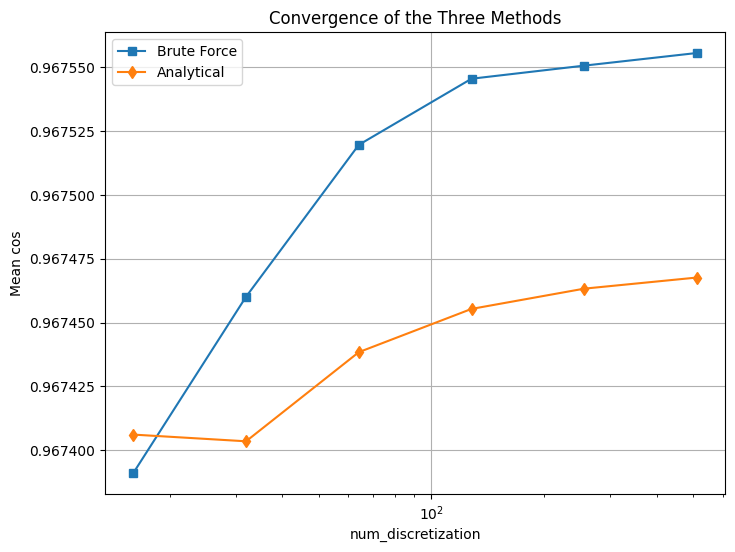

In [ ]:
import jax.numpy as jnp
import jax
import matplotlib.pyplot as plt
from scipy.special import ellipk, ellipj

# Integration parameters
dt = 0.1
num_steps = 500
num_discretization_values = jnp.array([16, 32, 64, 128, 256, 512])  # Different resolutions
num_samples_analytic = 128  # Number of samples for analytical integration

# Store results
weighted_means = []
brute_force_means = []
analytical_means = []

def analytical_trajectory(z0, lambda1, lambda2, lambda3, num_samples=100):
    """Computes analytical trajectories for z0 of shape (n, 3) and returns traj of shape (n, num_samples, 3)."""
    
    # Extract the components of z0
    x0, y0, z0_comp = z0[:, 0], z0[:, 1], z0[:, 2]  # Shape: (n,)

    # Compute trajectory parameters
    a = z0_comp**2 * lambda1 + y0**2 * lambda2 + x0**2 * lambda3  # Shape: (n,)
    alpha = jnp.sqrt((a - lambda3) / (lambda2 - lambda3))
    beta = jnp.sqrt((a - lambda1) / (lambda2 - lambda1))
    
    k = jnp.where(alpha < beta, alpha / beta, beta / alpha)
    gamma = jnp.sqrt((lambda2 - lambda3) / (lambda1 - lambda3)) * alpha
    delta = jnp.sqrt((lambda1 - lambda2) / (lambda1 - lambda3)) * beta
    mu = jnp.sqrt((lambda1 - lambda2) * (lambda2 - lambda3)) * jnp.where(alpha < beta, beta, alpha)
    
    # Compute the period
    period = 4 * ellipk(k**2) / mu  # Shape: (n,)

    # Time samples, shape: (n, num_samples)
    time_samples = jnp.linspace(0, 1, num_samples)[None, :] * period[:, None]  # Shape: (n, num_samples)

    # Compute Jacobi elliptic functions
    sn, cn, dn, _ = ellipj(mu[:, None] * time_samples, k[:, None]**2)  # Shape: (n, num_samples)

    # Compute the trajectory components
    traj_x = jnp.where(alpha[:, None] < beta[:, None], delta[:, None] * dn, delta[:, None] * cn)  # Shape: (n, num_samples)
    traj_y = jnp.where(alpha[:, None] < beta[:, None], alpha[:, None] * sn, beta[:, None] * sn)  # Shape: (n, num_samples)
    traj_z = jnp.where(alpha[:, None] < beta[:, None], -gamma[:, None] * cn, -gamma[:, None] * dn)  # Shape: (n, num_samples)

    # Stack into the final trajectory array (n, num_samples, 3)
    traj = jnp.stack([traj_x, traj_y, traj_z], axis=-1)  # Shape: (n, num_samples, 3)

    return traj

for num_discretization in num_discretization_values:
    n_theta, n_phi = num_discretization, 2 * num_discretization
    theta = jnp.linspace(1E-3, jnp.pi, n_theta)
    phi = jnp.linspace(1E-3, 2 * jnp.pi, n_phi)
    theta_grid, phi_grid = jnp.meshgrid(theta, phi, indexing='ij')

    z_grid = jnp.stack([
        jnp.sin(theta_grid) * jnp.cos(phi_grid),
        jnp.sin(theta_grid) * jnp.sin(phi_grid),
        jnp.cos(theta_grid)
    ], axis=-1)

    # Brute-force simulation
    z0_samples = z_grid.reshape(-1, 3)
    jacobian = jnp.sin(theta_grid).reshape(-1)
    
    # Brute force numerical integration
    z = jax.vmap(lambda z0: integrate_trajectory(z0, M2_, dt, num_steps))(z0_samples)
    z = z / jnp.linalg.norm(z, axis=-1, keepdims=True)

    cos_values = quadratic_ratio(z, M1_)
    brute_force_time_average = jnp.mean(cos_values, axis=-1)
    brute_force_mean = jnp.mean(brute_force_time_average * jacobian) / jnp.mean(jacobian)
    brute_force_means.append(brute_force_mean)

    # Analytical approach
    z = analytical_trajectory(z0_samples, lambda1, lambda2, lambda3, num_samples_analytic)

    cos_values =  quadratic_ratio(z, M1_)
    analytical_time_average = jnp.mean(cos_values, axis=-1)
    analytical_mean = jnp.mean(analytical_time_average * jacobian) / jnp.mean(jacobian)
    analytical_means.append(analytical_mean)

    print(f"Discretization: {num_discretization}, Brute Force Mean: {brute_force_mean}, Analytical Mean: {analytical_mean}")

# Convert lists to arrays for plotting
brute_force_means = jnp.array(brute_force_means)
analytical_means = jnp.array(analytical_means)

# Plot results
plt.figure(figsize=(8, 6))
plt.plot(num_discretization_values, brute_force_means, 's-', label='Brute Force')
plt.plot(num_discretization_values, analytical_means, 'd-', label='Analytical')
plt.xscale('log')
plt.xlabel('num_discretization')
plt.ylabel('Mean cos')
plt.legend()
plt.grid()
plt.title('Convergence of the two Methods')
plt.show()
